In [23]:
import matplotlib.pyplot as plt
import os
#from utilites import read_data_from_timestep
import numpy as np
import pandas as pd
import csv


folder_path = os.path.join("../data_for_plots", "moving_vs_resting_bubble", "line_data_rho1_v001_oscillating")

frames_cm_resting = []
frames_mrt_resting = []
frames_cm_moving = []
frames_mrt_moving = []

# n = np.arange(127, 999, 128)
# n = np.arange(127, 256, 128)
n = np.arange(0, 999, 1)

i = np.arange(len(n))

u_diff = np.empty(len(n))
rho_diff = np.empty(len(n))

diam_x_cm_resting = np.empty(len(n))   # x coordinate of the center of mass of the bubble
diam_x_mrt_resting = np.empty(len(n))  # x coordinate of the center of mass of the bubble
diam_x_cm_moving = np.empty(len(n))    # x coordinate of the center of mass of the bubble
diam_x_mrt_moving = np.empty(len(n))   # x coordinate of the center of mass of the bubble

for i_, n_ in zip(i, n):
    frame_cm_resting = pd.read_csv(os.path.join(folder_path, "cm_resting.%d.csv" % n_), delimiter="\t")
    frame_mrt_resting = pd.read_csv(os.path.join(folder_path, "mrt_resting.%d.csv" % n_), delimiter="\t")
    frame_cm_moving = pd.read_csv(os.path.join(folder_path, "cm_moving.%d.csv" % n_), delimiter="\t")
    frame_mrt_moving = pd.read_csv(os.path.join(folder_path, "mrt_moving.%d.csv" % n_), delimiter="\t")

    frames_cm_resting.append(frame_cm_resting)
    frames_mrt_resting.append(frame_mrt_resting)
    frames_cm_moving.append(frame_cm_moving)
    frames_mrt_moving.append(frame_mrt_moving)

    def find_diameter(pf, threshold=0.5):
        scale_factor = 1001/256  
        # paraview dumps 1001 grid points from line plot, 
        # while simluation domain is 256 
        counter = 0

        for pf_ in pf:
            if pf_ > threshold:
                counter += 1  # pf_

        ans = counter/scale_factor
        return ans

    diam_x_cm_resting[i_] = find_diameter(frame_cm_resting['PhaseField'])
    diam_x_mrt_resting[i_] = find_diameter(frame_mrt_resting['PhaseField'])
    diam_x_cm_moving[i_] = find_diameter(frame_cm_moving['PhaseField'])
    diam_x_mrt_moving[i_] = find_diameter(frame_mrt_moving['PhaseField'])


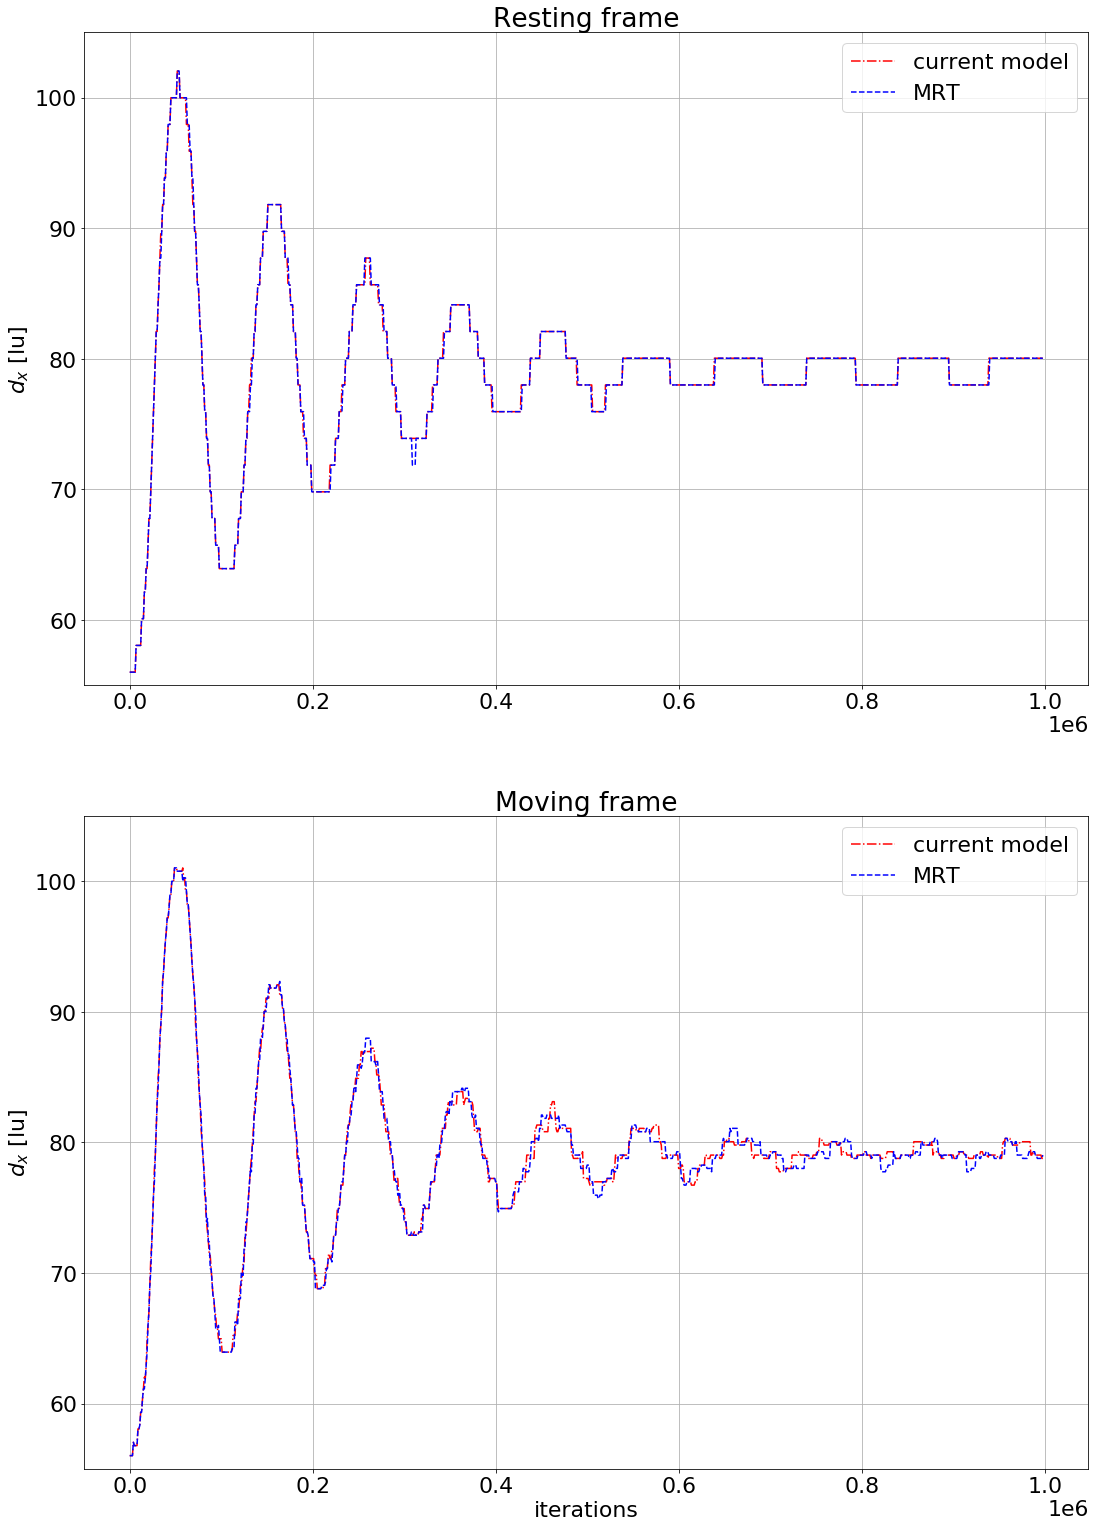

In [33]:
# make plot
plt.figure(1)
plt.figure(figsize=(18, 14))
plt.rcParams.update({'font.size': 22})

# frame_n = 1
# plt.plot(frames_cm_moving[frame_n]['arc_length'], frames_cm_moving[frame_n]['PhaseField'], color="green", marker="", linestyle="-.",  label='cm_test')
# plt.plot(frames_mrt_moving[frame_n]['arc_length'], frames_mrt_moving[frame_n]['PhaseField'], color="red", marker="", linestyle="-", label='mrt_test')

plt.subplot(211)
plt.title('Resting frame')


plt.plot(i*1E3, diam_x_cm_resting, color="red", marker="", linestyle="-.", label='current model')
plt.plot(i*1E3, diam_x_mrt_resting, color="blue", marker="", linestyle="--", label='MRT')
axes = plt.gca()
# axes.set_xlim([xmin,xmax])
axes.set_ylim([55, 105])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ylabel(r'$d_x$ [lu]')
# plt.xlabel(r'iterations')
plt.grid(True)
plt.legend()

plt.subplot(212)
plt.title(r'Moving frame')
plt.plot(i*1E3, diam_x_cm_moving, color="red", marker="", linestyle="-.", label='current model')
plt.plot(i*1E3, diam_x_mrt_moving, color="blue", marker="", linestyle="--", label='MRT')
# plt.plot(line_size, theoretical, color="black", marker="x", linestyle="", label='theoretical')
axes = plt.gca()
# axes.set_xlim([xmin,xmax])
axes.set_ylim([55, 105])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ylabel(r'$d_x$ [lu]')
plt.xlabel(r'iterations')
plt.grid(True)
plt.legend()

# plt.text(0.0, 0.0, r'cm_bubble diam = %.2f' % diam_x_cm_moving[frame_n])

fig = plt.gcf()  # get current figure
fig.savefig('bubble_diam.png')

plt.subplots_adjust(top=1.55)

plt.show()
#plt.close(fig)    # close the figure
